In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
import os

os.chdir("c:/Users/willi/nfl-predictor")

# Load model and features
with open("models/xgboost_wr.pkl", "rb") as f:
    model = pickle.load(f)

df = pd.read_parquet("data/processed/wr_features.parquet")

FEATURE_COLS = [
    'receiving_yards_roll3', 'receiving_yards_roll5',
    'targets_roll3', 'targets_roll5',
    'receptions_roll3', 'receptions_roll5',
    'target_share_roll3', 'target_share_roll5',
    'wopr_roll3', 'wopr_roll5',
    'receiving_epa_roll3', 'receiving_epa_roll5',
    'yards_season_avg', 'targets_season_avg',
    'opp_yards_allowed_per_game', 'is_home'
]

# Use 2024 test set only
test = df[df['season'] == 2024].copy()
X_test = test[FEATURE_COLS]

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print(f"SHAP values computed for {len(X_test):,} games")
print("Ready to plot")

SHAP values computed for 2,048 games
Ready to plot


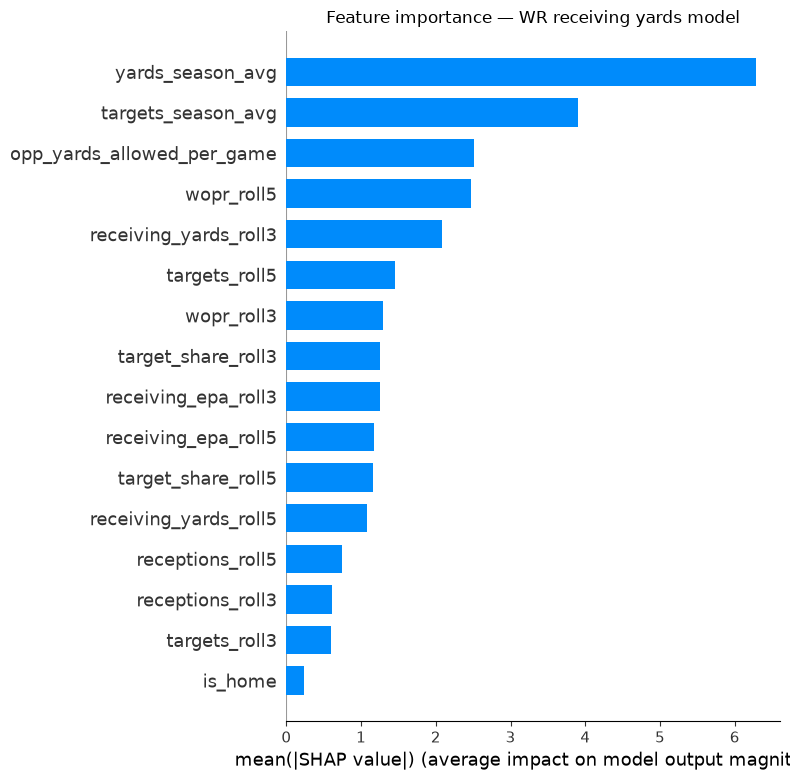

In [2]:
# Summary plot — feature importance ranked by impact
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature importance — WR receiving yards model")
plt.tight_layout()
plt.show()

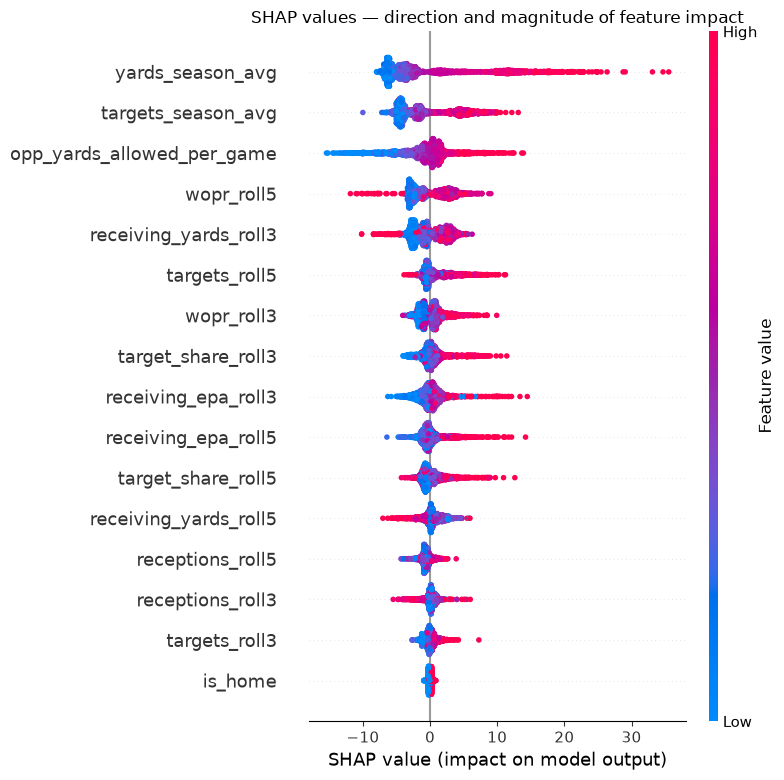

In [3]:
# Dot summary plot — shows direction of impact too
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP values — direction and magnitude of feature impact")
plt.tight_layout()
plt.show()